## 1. Problem Statement :- we have to predict house price

In [2]:
#2. Import Libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation & Exploration

In [8]:
#3. Load Dataset
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:
df.shape

(545, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [13]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [16]:
df.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [17]:
sns.set_style('darkgrid')

## Correlation with Price (Target Column)

In [18]:
df.corr(numeric_only = True)['price'].sort_values(ascending = False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

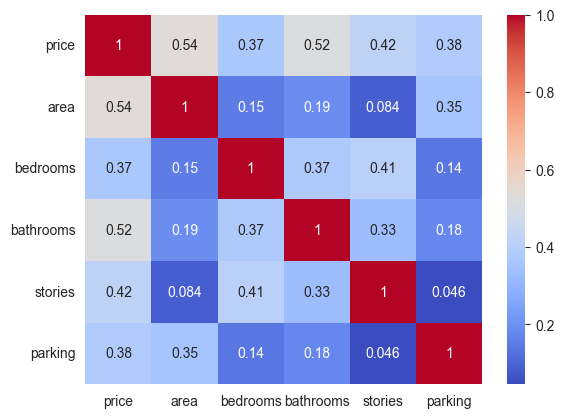

In [20]:
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap='coolwarm')
plt.show()

## Correlation (Numerical Columns with Price)

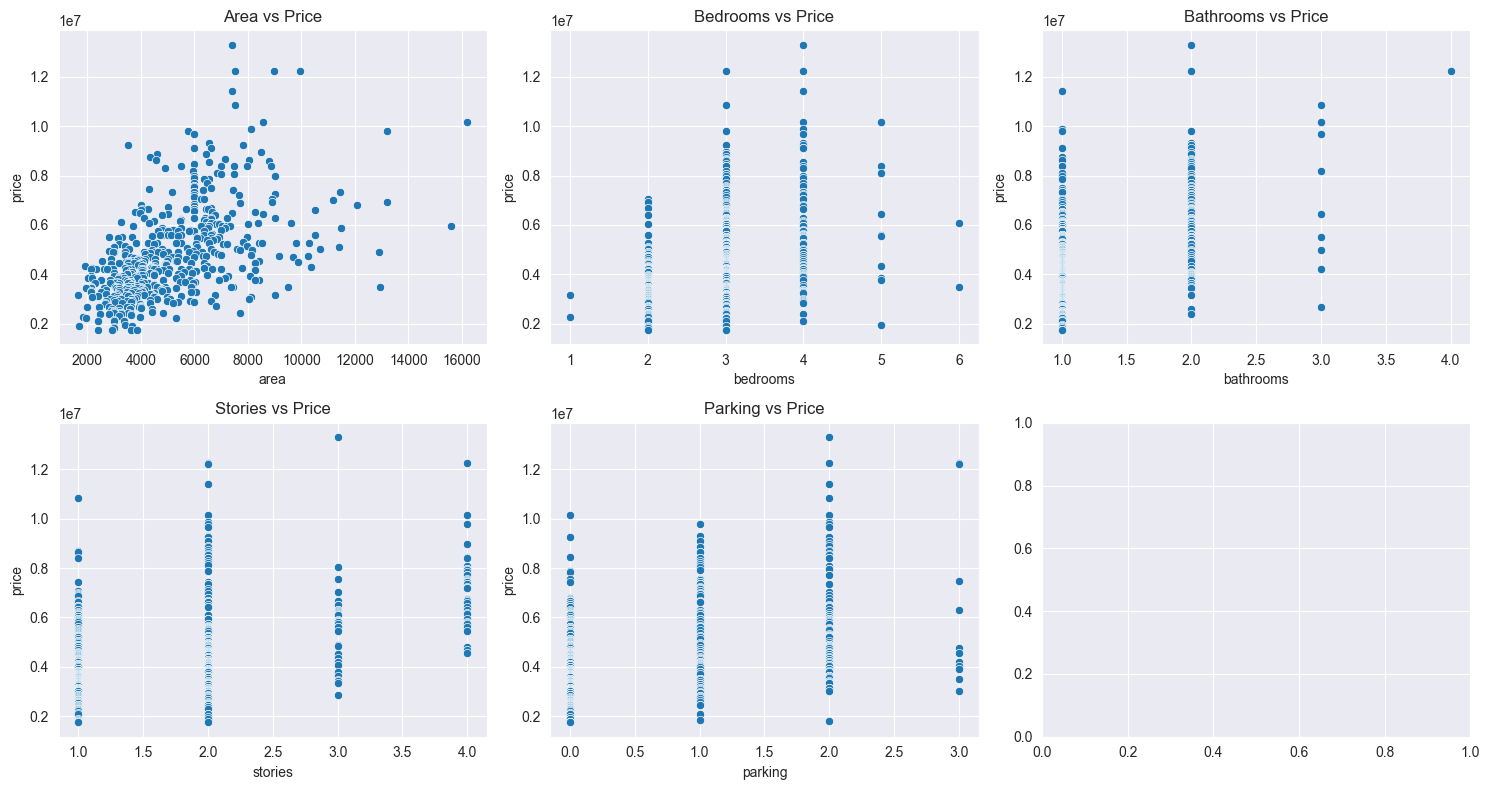

In [24]:
fig, ax = plt.subplots(2, 3, figsize = (15, 8))
sns.scatterplot(data=df, x='area', y='price', ax=ax[0,0])
ax[0,0].set_title('Area vs Price')

sns.scatterplot(data=df, x='bedrooms', y='price', ax=ax[0,1])
ax[0,1].set_title('Bedrooms vs Price')

sns.scatterplot(data=df, x='bathrooms', y='price', ax=ax[0,2])
ax[0,2].set_title('Bathrooms vs Price')

sns.scatterplot(data=df, x='stories', y='price', ax=ax[1,0])
ax[1,0].set_title('Stories vs Price')

sns.scatterplot(data=df, x='parking', y='price', ax=ax[1, 1])
ax[1,1].set_title('Parking vs Price')

plt.tight_layout()
plt.show()

## Correlation (Categorical Columns with Price)

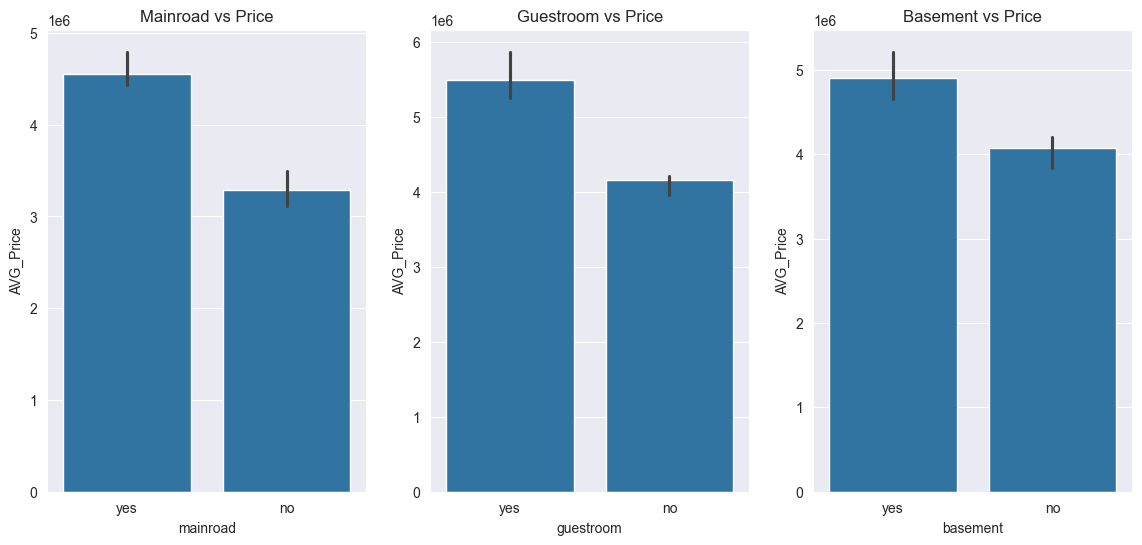

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

sns.barplot(data=df, x='mainroad', y='price', estimator='median', ax=ax[0], order=['yes', 'no'])
ax[0].set_title('Mainroad vs Price')
ax[0].set_ylabel('AVG_Price')

sns.barplot(data=df, x='guestroom', y='price', estimator='median', ax=ax[1], order=['yes', 'no'])
ax[1].set_title('Guestroom vs Price')
ax[1].set_ylabel('AVG_Price')

sns.barplot(data=df, x='basement', y='price', estimator='median', ax=ax[2], order=['yes', 'no'])
ax[2].set_title('Basement vs Price')
ax[2].set_ylabel('AVG_Price')

plt.show()

In [27]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [29]:
piv = df.pivot_table(index='furnishingstatus', values='price', aggfunc='median')
piv.reset_index(inplace = True)
piv

,furnishingstatus,price
0,furnished,5075000.0
1,semi-furnished,4585000.0
2,unfurnished,3430000.0


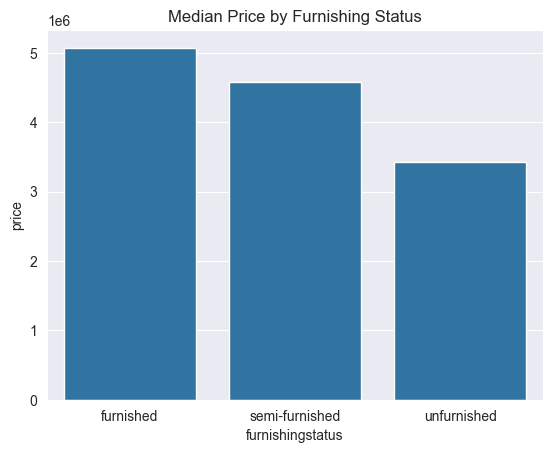

In [34]:
sns.barplot(data=piv, x='furnishingstatus', y='price')
plt.title("Median Price by Furnishing Status")
plt.show()

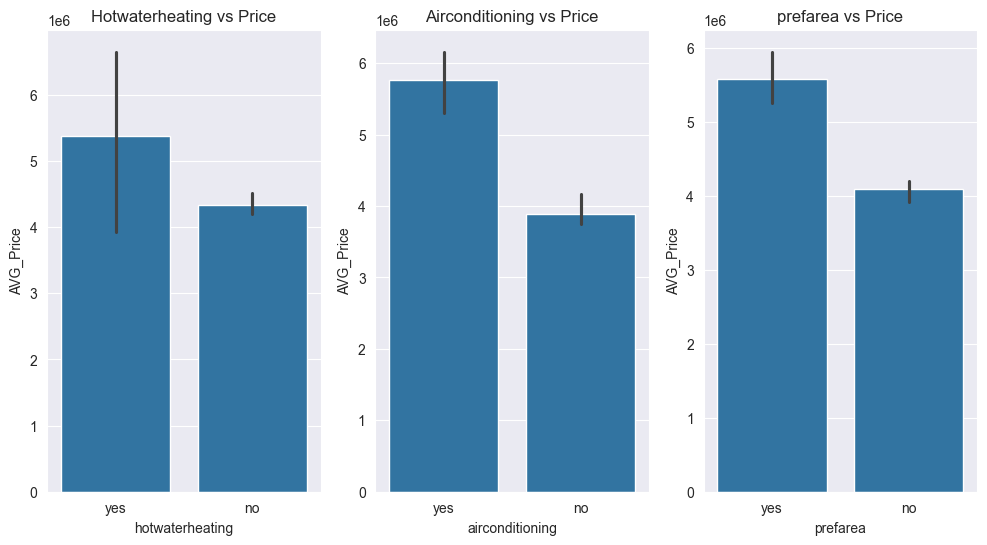

In [36]:
fig , ax = plt.subplots(1,3,figsize=(12,6))

sns.barplot(data=df,x='hotwaterheating',y='price',estimator='median',ax=ax[0],order=['yes','no'])
ax[0].set_title('Hotwaterheating vs Price')
ax[0].set_ylabel('AVG_Price')

sns.barplot(data=df,x='airconditioning',y='price',estimator='median',ax=ax[1],order=['yes','no'])
ax[1].set_title('Airconditioning vs Price')
ax[1].set_ylabel('AVG_Price')

sns.barplot(data=df,x='prefarea',y='price',estimator='median',ax=ax[2],order=['yes','no'])
ax[2].set_title('prefarea vs Price')
ax[2].set_ylabel('AVG_Price')


plt.show()

## Handling Outliers

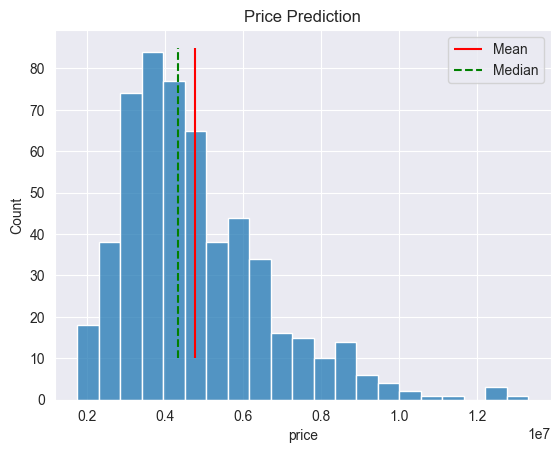

In [37]:
sns.histplot(data=df, x = 'price')
plt.vlines(x=df['price'].mean(), ymin = 10, ymax = 85, linestyles = 'solid', color='red')
plt.vlines(x=df['price'].median(), ymin = 10, ymax = 85, linestyles = 'dashed', color='green')
plt.title('Price Prediction')
plt.legend(['Mean', 'Median'])
plt.show()

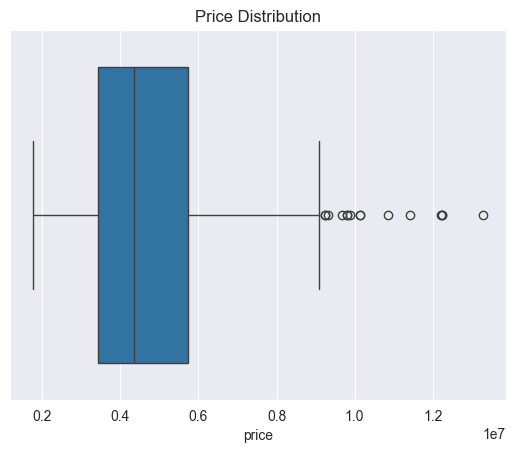

In [38]:
sns.boxplot(data=df, x='price')
plt.title('Price Distribution')
plt.show()

In [39]:
df['price'].quantile([0,0.25,0.5,0.75,1])

0.00     1750000.0
0.25     3430000.0
0.50     4340000.0
0.75     5740000.0
1.00    13300000.0
Name: price, dtype: float64

In [41]:
IQR = df['price'].quantile(0.75) - df['price'].quantile(0.25)
upperBound = 5740000.0 + IQR*1.5
lowerBound = 3430000.0 - IQR*1.5

In [43]:
df[df['price'] > upperBound]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [46]:
df[df['price'] < lowerBound]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus


In [47]:
df = df[df['price']<=upperBound]

In [48]:
df.shape

(530, 13)

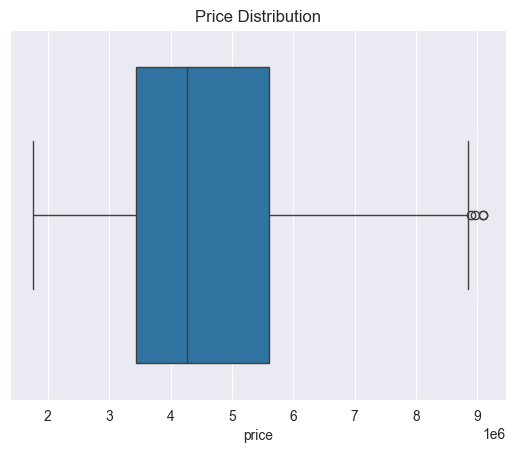

In [49]:
sns.boxplot(data=df, x='price')
plt.title('Price Distribution')
plt.show()

## Data Preprocessing

In [50]:
X = df.drop(columns = 'price')
Y = df['price']

## One Hot Encoding

In [54]:
X = pd.get_dummies(data=X, drop_first=True, dtype=int)
X

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
15,6000,4,1,2,2,1,0,1,0,0,0,1,0
16,6600,4,2,2,1,1,1,1,0,1,1,0,1
17,8500,3,2,4,2,1,0,0,0,1,0,0,0
18,4600,3,2,2,2,1,1,0,0,1,0,0,0
19,6420,3,2,2,1,1,0,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [58]:
import statsmodels.api as sm
X = sm.add_constant(X)
print(sm.OLS(Y,X).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     79.38
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          5.94e-114
Time:                        21:36:12   Log-Likelihood:                -8030.4
No. Observations:                 530   AIC:                         1.609e+04
Df Residuals:                     516   BIC:                         1.615e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [59]:
X.drop(columns=['const','bedrooms','furnishingstatus_semi-furnished'],inplace=True)

## train_test_split

In [60]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.25,random_state=40)

## Feature Scaling

In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train)
X_test_full = scaler.fit_transform(X_test)

## Building model by Linear Regression

In [64]:
from sklearn.linear_model import LinearRegression
line_reg = LinearRegression()
line_reg.fit(X_train_full, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
y_test_pred = line_reg.predict(X_test_full)

In [69]:
from sklearn.metrics import  mean_squared_error, r2_score
MSE = mean_squared_error(y_test, y_test_pred)
RMSE = np.sqrt(MSE)
r2 = r2_score(y_test, y_test_pred)

In [71]:
print('MSE : ',MSE)
print('RMSE : ',RMSE)
print('R2 : ',r2)

MSE :  933212539928.105
RMSE :  966029.2645298614
R2 :  0.6846561755165387


In [72]:
from sklearn.linear_model import Ridge
rid = Ridge(alpha=0.01)
rid.fit(X_train_full,y_train)

,alpha,0.01
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [73]:
y_test_pred = rid.predict(X_test_full)

In [74]:
from sklearn.metrics import mean_squared_error , r2_score
MSE = mean_squared_error(y_test,y_test_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test,y_test_pred)


In [75]:
print('MSE : ',MSE)
print('RMSE : ',RMSE)
print('R2 : ',R2)

MSE :  933215281335.504
RMSE :  966030.6834337635
R2 :  0.6846552491617623


## Summary

In [ ]:
Housing Price Prediction Project Summary 🏠

Project Goal: Develop a Machine Learning model to predict house prices using numerical and categorical features, while improving model accuracy by removing outliers.

1️⃣ Exploratory Data Analysis (EDA)

Checked dataset shape and types (df.info(), df.describe(), df.head()).

Verified missing values and duplicates (isnull().sum(), duplicated().sum()).

Analyzed relationships between features and price:

Scatter plots for numerical features (area, bedrooms, stories, bathrooms, parking).

Bar plots and pie chart for categorical features (mainroad, guestroom, basement, furnishingstatus, airconditioning, prefarea).

Examined price distribution:

Histogram and boxplot to check skewness and outliers.

2️⃣ Outlier Handling

Calculated IQR for price to identify upper and lower bounds.

Removed values outside these bounds.

After removing outliers → R² improved from ~0.686 → 0.70.

3️⃣ Data Preprocessing & Feature Engineering

Separated X (features) and Y (target).

No log transformation applied to the target.

Applied One-Hot Encoding for categorical features.

Dropped some columns after OLS to reduce multicollinearity (optional).

Used StandardScaler to scale numerical features.

4️⃣ Train/Test Split

Split data into training and testing sets (75% train / 25% test).

Used random_state=40 for reproducibility.

5️⃣ Models Used

Linear Regression

Classic linear model suitable after preprocessing and outlier removal.

R² ≈ 0.70.

Ridge Regression

Linear model with L2 regularization to reduce overfitting.

Results similar to Linear Regression due to stable data.

Linear SGDRegressor

Linear model trained with stochastic gradient descent.

Results very close to Linear Regression because of small, stable dataset.

6️⃣ Model Evaluation

Metrics used:

MSE = 0.0517

RMSE = 0.2273

R² ≈ 0.70

Model explains about 70% of price variance → good performance for a linear model.

7️⃣ General Notes & Potential Improvements

Data is clean after outlier removal → linear models are stable and perform well.

To improve R² further:

Feature Engineering: add interaction terms or polynomial features.

Use non-linear models: Random Forest, Gradient Boosting, XGBoost.

Regularization (Ridge/Lasso) helps if overfitting appears, but its effect here is limited.

Conclusion: The project is well-organized: EDA → preprocessing → modeling → evaluation. The current linear model gives good accuracy (R² ≈ 0.70) after removing outliers. Any further improvement relies on feature engineering or using non-linear models.